In [15]:
import numpy as np
import matplotlib.pyplot as plt

In [16]:
T_max = 10
dt = 0.01
steps = int(T_max / dt)
tau = np.linspace(0.1, T_max, 100)
sigma = 0.01

f0 = 0.05 * np.exp(-0.3 * tau)

In [17]:
def sim_HJM(f0, sigma, dt, steps, tau):
    n = len(tau)
    f = np.zeros((steps, n))
    f[0] = f0.copy()

    for t in range(1, steps):
        z = np.random.normal(0,1)
        for i in range(n):
            T = tau[i]
            drift = sigma * sigma * (T - dt*t)
            f[t, i] = f[t-1, i] + drift * dt + sigma * np.sqrt(dt) * z
    return f

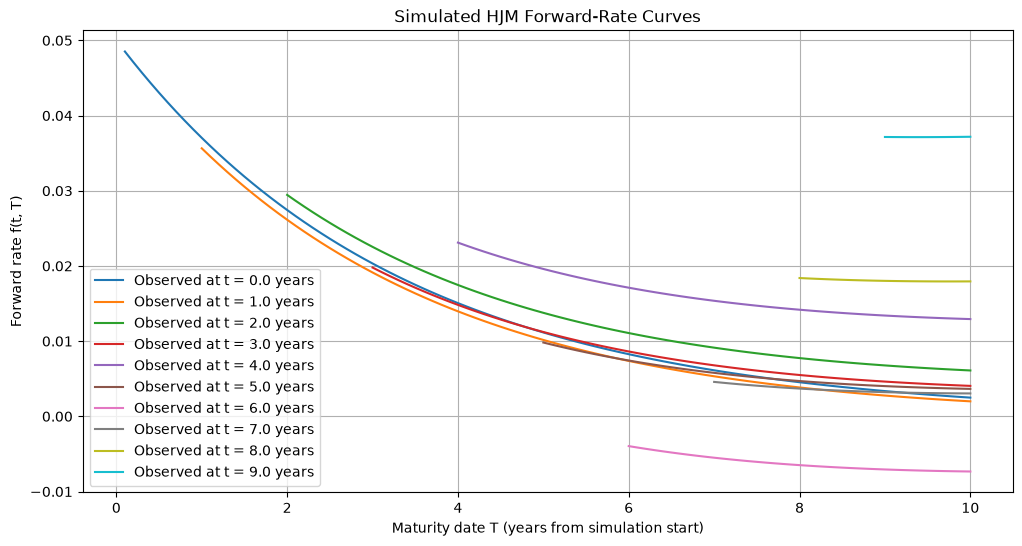

In [18]:
f_hjm = sim_HJM(f0, sigma, dt, steps, tau)

plt.figure(figsize=(12, 6))

for t in range(0, steps, int(steps / 10)):
    current_time = t * dt

    # Only plot maturities that have not already passed
    valid = tau >= current_time

    plt.plot(
        tau[valid],
        f_hjm[t, valid],
        label=f"Observed at t = {current_time:.1f} years"
    )

plt.title("Simulated HJM Forward-Rate Curves")
plt.xlabel("Maturity date T (years from simulation start)")
plt.ylabel("Forward rate f(t, T)")
plt.legend()
plt.grid(True)
plt.show()

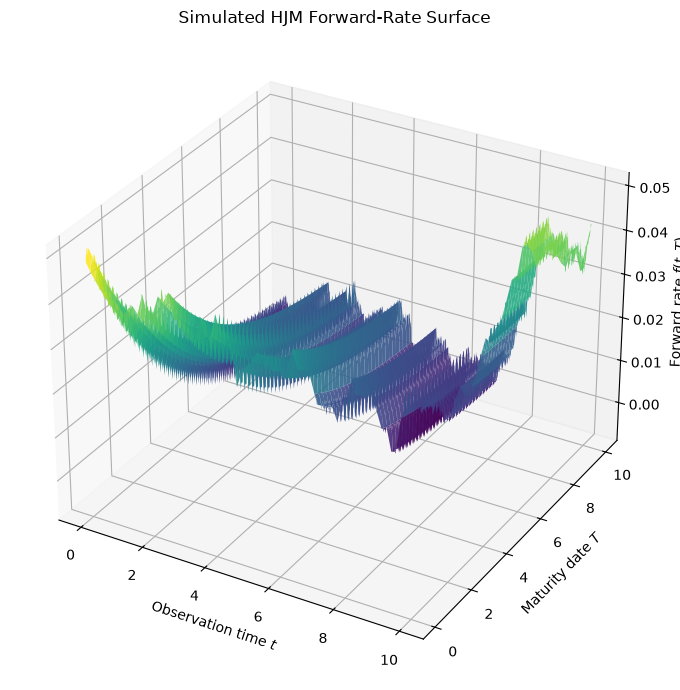

In [19]:
from mpl_toolkits.mplot3d import Axes3D

# Observation times
time_grid = np.arange(steps) * dt

# Construct coordinate grids
T_mesh, t_mesh = np.meshgrid(tau, time_grid)

# Forward rates only make sense for T >= t
f_surface = f_hjm.copy()
f_surface[T_mesh < t_mesh] = np.nan

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    t_mesh,
    T_mesh,
    f_surface,
    cmap="viridis",
    edgecolor="none",
    alpha=0.9
)

ax.set_title("Simulated HJM Forward-Rate Surface")
ax.set_xlabel(r"Observation time $t$")
ax.set_ylabel(r"Maturity date $T$")
ax.set_zlabel(r"Forward rate $f(t,T)$")

plt.tight_layout()
plt.show()